# Домашнее задание 3


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
%matplotlib inline
import pandas as pd

In [2]:
! pip install gdown==4.6.3

## 1. Оптимизация модулярности (теория) (4 балла)

Рассмотрим граф-цикл $C_N$ на $N$ вершинах: каждая вершина имеет ровно две связи с соседними вершинами, расположенными на окружности (ниже пример для $N=10$). Рассмотрим разделение графа на $k$ последовательных сообществ, размера $n=N/k$:  т.е. сообщества формируют вершины соседствующие на окружности (см. Рисунок). Определите оптимальные размер кластера и число кластеров на графе, считая что оптимальное разбиение соответвует максимальной модулярности. Для простоты считайте, что $n$ целое.

Пример разбиения: 

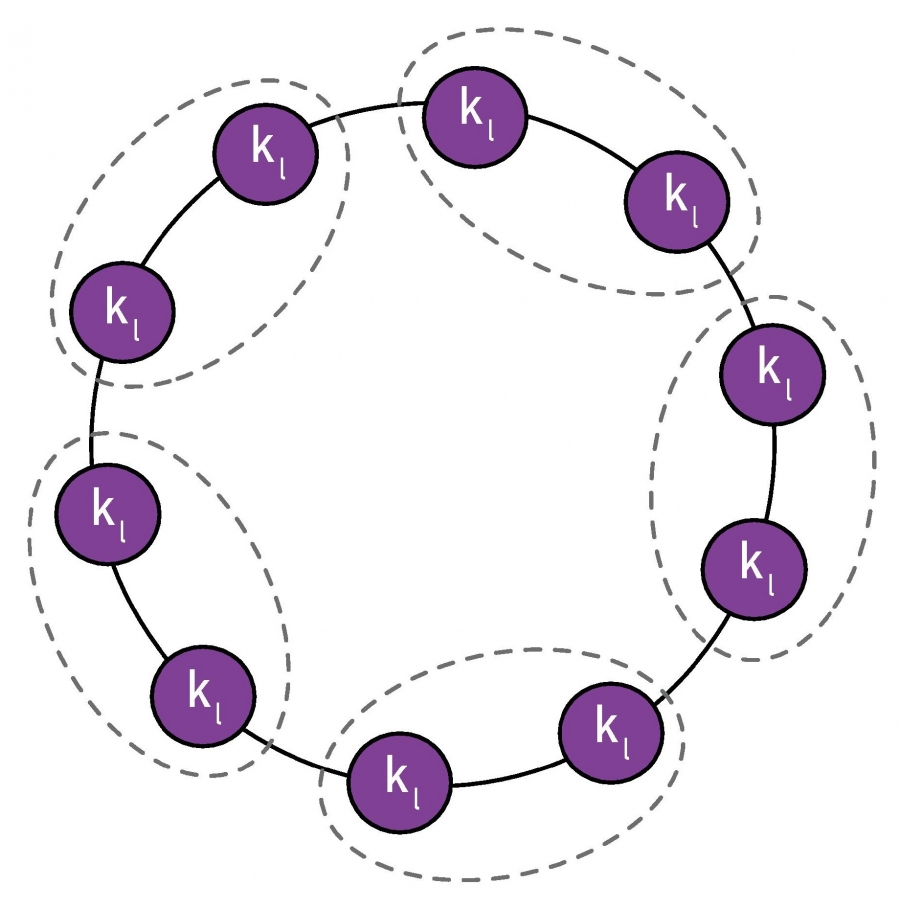

## Решение

Рассмотрим цикл $C_N$ с $N$ вершинами и $N$ рёбрами ($m = N$). Каждая вершина имеет степень 2. Разобьём граф на $k$ последовательных кластеров одинакового размера: $n = \frac{N}{k}$

### 1. Параметры одного кластера

Для каждого кластера:

- Число внутренних рёбер: $ l = n - 1 $, так как внутри кластера получается цепочка из $n$ вершин

- Суммарная степень вершин: $ d = 2n $

### 2. Формула модулярности

Модулярность:

$ Q = \sum_{c=1}^{k} \left( \frac{l_c}{m} - \left(\frac{d_c}{2m}\right)^2 \right) $

Подставим значения для каждого кластера:

$ Q = k \left( \frac{n-1}{N} - \left(\frac{2n}{2N}\right)^2 \right) $

Упростим:

$ Q = k \left( \frac{n-1}{N} - \left(\frac{n}{N}\right)^2 \right) $

### 3. Подставим $n = \frac{N}{k}$

$ \frac{n-1}{N} = \frac{N/k - 1}{N} = \frac{1}{k} - \frac{1}{N} $

$ \left(\frac{n}{N}\right)^2 = \left(\frac{1}{k}\right)^2 $

Тогда:

$ Q = k \left( \frac{1}{k} - \frac{1}{N} - \frac{1}{k^2} \right) $

$ Q = 1 - \frac{1}{k} - \frac{k}{N} $

### 4. Оптимизация

Максимизируем:
$ Q(k) = 1 - \frac{1}{k} - \frac{k}{N} $

Рассмотрим $k$ как непрерывную переменную и найдём производную:

$ \frac{dQ}{dk} = \frac{1}{k^2} - \frac{1}{N} $

Приравниваем к нулю:


$ \frac{1}{k^2} = \frac{1}{N} $
$ \Rightarrow k = \sqrt{N} $

### 5. Итог

Оптимальные параметры:

- **Число кластеров:**
$ k^* \approx \sqrt{N} $

- **Размер кластера:**
$ n^* = \frac{N}{k^*} \approx \sqrt{N} $

С учётом целочисленности:
- $k$ выбирается как ближайший делитель $N$ к $\sqrt{N}$

## 2. Поиск сообществ (6 балла)

* Для задачи испольйте [данные](https://snap.stanford.edu/data/email-Eu-core.html) (предварительно сделайте сеть ненаправленной).

 Каждый сотдрудник относится к одному из департаментов, которые и являются истинными сообществами в сети.

1. Постройте распределение размеров сообществ в сети, какова доля вершин в наибольшем сообществе? В наименьшем?

2. Определите сообщества с помощью различных алгоритмов. Сравните взаимную информацию истинного разбиения и полученного различными методами. Какой из методов точнее?

3. Какой из методов позволяет точнее обнаружить самый большой кластер? Самый маленький кластер?

In [ ]:
import gzip

edges = []
with gzip.open('email-Eu-core.txt.gz', 'rt') as f:
    for line in f:
        u, v = map(int, line.strip().split())
        edges.append((u, v))

G = nx.Graph()
G.add_edges_from(edges)

print(f"Число вершин: {G.number_of_nodes()}")
print(f"Число рёбер: {G.number_of_edges()}")

labels = {}
with gzip.open('email-Eu-core-department-labels.txt.gz', 'rt') as f:
    for line in f:
        node, dep = map(int, line.strip().split())
        labels[node] = dep

print(f"Число размеченных вершин: {len(labels)}")

Число вершин: 1005
Число рёбер: 16706
Число размеченных вершин: 1005


In [4]:
# считаем размеры сообществ
from collections import Counter

community_sizes = Counter(labels.values())

sizes = np.array(list(community_sizes.values()))

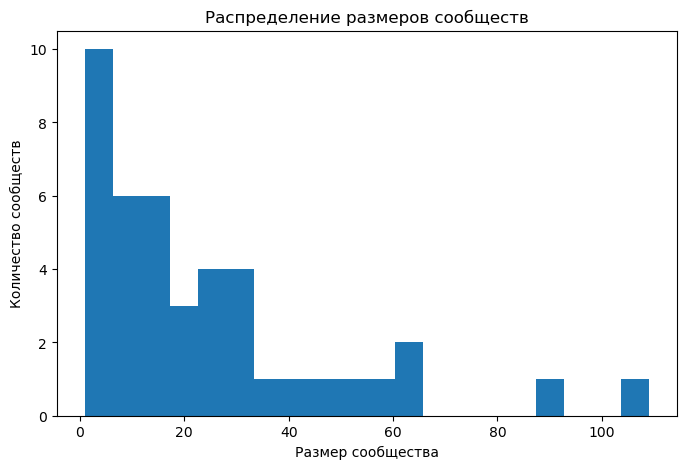

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(sizes, bins=20)
plt.xlabel("Размер сообщества")
plt.ylabel("Количество сообществ")
plt.title("Распределение размеров сообществ")
plt.show()

In [6]:
# доли
total_nodes = len(labels)

print(f"Число сообществ: {len(sizes)}")
print(f"Максимальный размер: {sizes.max()}")
print(f"Минимальный размер: {sizes.min()}")
print(f"Доля в крупнейшем сообществе: {sizes.max() / total_nodes:.4f}")
print(f"Доля в наименьшем сообществе: {sizes.min() / total_nodes:.4f}")

Число сообществ: 42
Максимальный размер: 109
Минимальный размер: 1
Доля в крупнейшем сообществе: 0.1085
Доля в наименьшем сообществе: 0.0010


In [7]:
from sklearn.metrics import normalized_mutual_info_score

nodes = list(G.nodes())
true_labels = np.array([labels[node] for node in nodes])

In [ ]:
import networkx.algorithms.community as nx_comm

results = {}

# Greedy
communities_greedy = list(nx_comm.greedy_modularity_communities(G))
pred_greedy = {}

for i, comm in enumerate(communities_greedy):
    for node in comm:
        pred_greedy[node] = i

pred_labels_greedy = np.array([pred_greedy[node] for node in nodes])

nmi_greedy = normalized_mutual_info_score(true_labels, pred_labels_greedy)
results['Greedy'] = nmi_greedy


# Label Propagation
communities_lp = list(nx_comm.label_propagation_communities(G))
pred_lp = {}

for i, comm in enumerate(communities_lp):
    for node in comm:
        pred_lp[node] = i

pred_labels_lp = np.array([pred_lp[node] for node in nodes])

nmi_lp = normalized_mutual_info_score(true_labels, pred_labels_lp)
results['Label Propagation'] = nmi_lp


# Girvan-Newman
comp = nx_comm.girvan_newman(G)

for communities_gn in comp:
    if len(communities_gn) >= 42:
        break

communities_gn = list(communities_gn)

pred_gn = {}
for i, comm in enumerate(communities_gn):
    for node in comm:
        pred_gn[node] = i

pred_labels_gn = np.array([pred_gn[node] for node in nodes])

nmi_gn = normalized_mutual_info_score(true_labels, pred_labels_gn)
results['Girvan-Newman'] = nmi_gn


for method, score in results.items():
    print(f"{method}: NMI = {score:.4f}")

Greedy: NMI = 0.4780
Label Propagation: NMI = 0.1803
Girvan-Newman: NMI = 0.0768


Лучший метод: Greedy modularity

In [ ]:
from collections import defaultdict

def analyze_extreme_clusters(pred_labels, name):
    print(f"\n{name}")
    
    # истинные кластеры
    true_comms = defaultdict(set)
    for node, label in labels.items():
        true_comms[label].add(node)
    
    # предсказанные кластеры
    pred_comms = defaultdict(set)
    for node, label in zip(nodes, pred_labels):
        pred_comms[label].add(node)
    
    # экстремальные истинные
    largest_true = max(true_comms.values(), key=len)
    smallest_true = min(true_comms.values(), key=len)
    
    def best_match(true_cluster):
        best_overlap = 0
        best_pred = None
        
        for pred_cluster in pred_comms.values():
            overlap = len(true_cluster & pred_cluster)
            if overlap > best_overlap:
                best_overlap = overlap
                best_pred = pred_cluster
        
        precision = best_overlap / len(best_pred)
        recall = best_overlap / len(true_cluster)
        
        return precision, recall, best_overlap
    
    # анализ
    p_big, r_big, o_big = best_match(largest_true)
    p_small, r_small, o_small = best_match(smallest_true)
    
    print(f"Большой кластер: precision={p_big:.3f}, recall={r_big:.3f}")
    print(f"Малый кластер: precision={p_small:.3f}, recall={r_small:.3f}")


# запускаем для всех методов
analyze_extreme_clusters(pred_labels_greedy, "Greedy")
analyze_extreme_clusters(pred_labels_lp, "Label Propagation")
analyze_extreme_clusters(pred_labels_gn, "Girvan-Newman")


Greedy
Большой кластер: precision=0.308, recall=0.908
Малый кластер: precision=0.003, recall=1.000

Label Propagation
Большой кластер: precision=0.119, recall=0.972
Малый кластер: precision=0.001, recall=1.000

Girvan-Newman
Большой кластер: precision=0.109, recall=0.963
Малый кластер: precision=0.001, recall=1.000


- precision — доля вершин найденного кластера, принадлежащих истинному,
- recall — доля вершин истинного кластера, найденных алгоритмом.

### Сравнение по методам

| Метод | Большой (precision) | Большой (recall) | Малый (precision) | Малый (recall) |
|-|-|-|-|-|
| Greedy | 0.308 | 0.908 | 0.003 | 1.000 |
| Label Propagation | 0.119 | 0.972 | 0.001 | 1.000 |
| Girvan–Newman | 0.109  | 0.963 | 0.001 | 1.000 |

---

### Выводы

#### Крупнейшее сообщество

- Все методы показывают высокий recall. Они почти полностью находят крупнейший кластер.
- Greedy*даёт наилучший precision (0.308)
- остальные методы сильно "засоряют" кластер лишними вершинами

#### Наименьшее сообщество

- Recall = 1.0 у всех методов. Алгоритмы не теряют вершину
- precision = 0. Вершина включается в огромный кластер
Ни один метод не умеет корректно выделять маленькие сообщества

### Итог

- Лучший метод в целом: Greedy modularity  

## 3. SI модель в случайных сетях (4 баллов)

* Сгенерируйте случайные графы из разных моделей: Эрдеша-Реньи, Барабаши-Альберта, Ваттса-Строгатца, геометрическая сеть и т.д.

Число вершин всех графов $N=10^4$, а средняя степень у всех примерно одинакова и, например, $\left< k\right>\approx10$.

* Смоделируйте SI модель, изобразите на одном графике среднюю долю инфицированных от времени для разных графов.  

Параметры модели SI - $\beta$ и число шагов по времени - подберите самостоятельно.

На этом же графике изобразите кривую, отвечающую приближению среднего поля (из семинара).

* Объясните результаты.

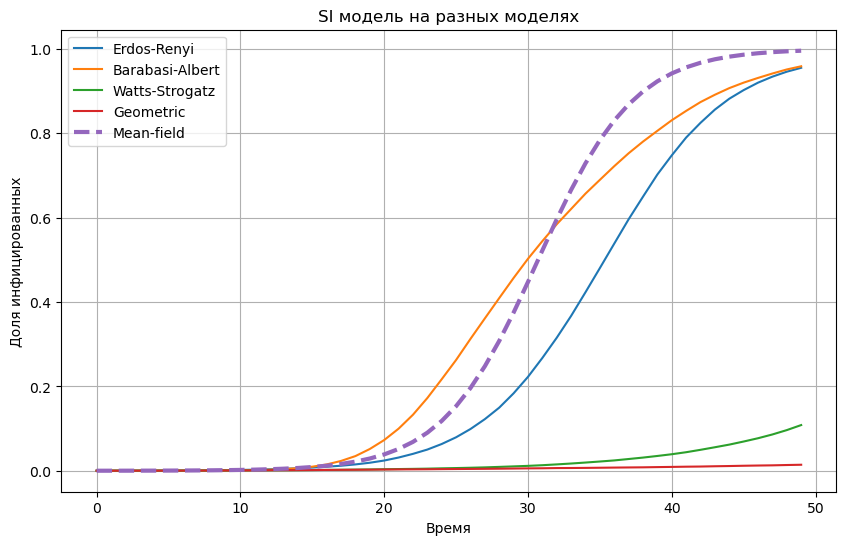

In [10]:
# параметры
N = 10000
k_avg = 10
T = 50
beta = 0.03
runs = 5  # усреднение по запускам

# генерация графов
p = k_avg / (N - 1)

G_er = nx.erdos_renyi_graph(N, p)

G_ba = nx.barabasi_albert_graph(N, m=k_avg // 2)

G_ws = nx.watts_strogatz_graph(N, k=k_avg, p=0.1)

radius = np.sqrt(k_avg / (np.pi * N))
G_geo = nx.random_geometric_graph(N, radius)

graphs = {
    "Erdos-Renyi": G_er,
    "Barabasi-Albert": G_ba,
    "Watts-Strogatz": G_ws,
    "Geometric": G_geo
}

# SI модель
def run_si(G, beta, T):
    nodes = list(G.nodes())
    infected = set([np.random.choice(nodes)])
    infected_fraction = []

    for t in range(T):
        new_infected = set(infected)
        
        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected:
                    if np.random.rand() < beta:
                        new_infected.add(neighbor)
        
        infected = new_infected
        infected_fraction.append(len(infected) / len(nodes))
    
    return np.array(infected_fraction)

# усреднение
results = {}

for name, G in graphs.items():
    all_runs = []
    
    for _ in range(runs):
        all_runs.append(run_si(G, beta, T))
    
    results[name] = np.mean(all_runs, axis=0)

# приближение среднего поля
t = np.arange(T)
I0 = 1 / N

I_mf = (I0 * np.exp(beta * k_avg * t)) / (1 - I0 + I0 * np.exp(beta * k_avg * t))


plt.figure(figsize=(10, 6))

for name, curve in results.items():
    plt.plot(curve, label=name)

plt.plot(I_mf, '--', label='Mean-field', linewidth=3)

plt.xlabel("Время")
plt.ylabel("Доля инфицированных")
plt.title("SI модель на разных моделях")
plt.legend()
plt.grid()

plt.show()

Было использовано приближение среднего поля:
$$
x(t)=\frac{x_0 e^{\beta \langle k \rangle t}}{1 - x_0 + x_0 e^{\beta \langle k \rangle t}}
$$

### Самое быстрое распространение — Barabasi–Albert

Инфекция распространяется быстрее всего в графе Барабаши–Альберта, т.к. присутствуют вершины с очень большой степенью, которые быстро заражают большое число соседей

### Сравнение с приближением среднего поля

Приближение среднего пол я предсказывает более быстрый рост, чем в большинстве реальных графов, т.к. приближение предполагает случайные контакты и отсутствие структуры графа. В реальных графах есть кластеры, неоднородности, а также ограничения на распространение. Поэтому остальные модели медленнее, чем приближение среднего поля.

*Вывод:*
- Структура графа существенно влияет на скорость распространения инфекции.
- Наличие хабов ускоряет распространение.
- Локальность связей замедляет распространение.
- Приближение среднего поля не учитывает структуру сети и даёт усреднённую оценку динамики.

## 4. SIR на сетях различной структуры (4 баллов)
Рассмотрим модель SIR на следующих сетях:

In [11]:
!gdown 13hlp2ZU0idFzJR-8RXGO4FOp4OI8y6Uo

Downloading...
From: https://drive.google.com/uc?id=13hlp2ZU0idFzJR-8RXGO4FOp4OI8y6Uo
To: /Users/v.makshanchikov/Documents/Python Proj/Графы ДЗ 3/graph1.graphml
100%|████████████████████████████████████████| 769k/769k [00:00<00:00, 2.93MB/s]


In [12]:
!gdown 1xkAOK6sp8PsUFKGea2G-oQd8JGDF_Qgh

Downloading...
From: https://drive.google.com/uc?id=1xkAOK6sp8PsUFKGea2G-oQd8JGDF_Qgh
To: /Users/v.makshanchikov/Documents/Python Proj/Графы ДЗ 3/graph2.graphml
100%|████████████████████████████████████████| 769k/769k [00:00<00:00, 3.00MB/s]


In [13]:
G1=nx.read_graphml('graph1.graphml')
G2=nx.read_graphml('graph2.graphml')

* Постройте зависимости средней доли зараженных вершин в модели SIR для первого и второго графа.

Параметры для моделирования:

In [14]:
beta=0.005
gamma=0.03
percentage_infected=0.002
n_iter=200 # число шагов моделирования
n_run=100 # число запусков распространения для усреднения

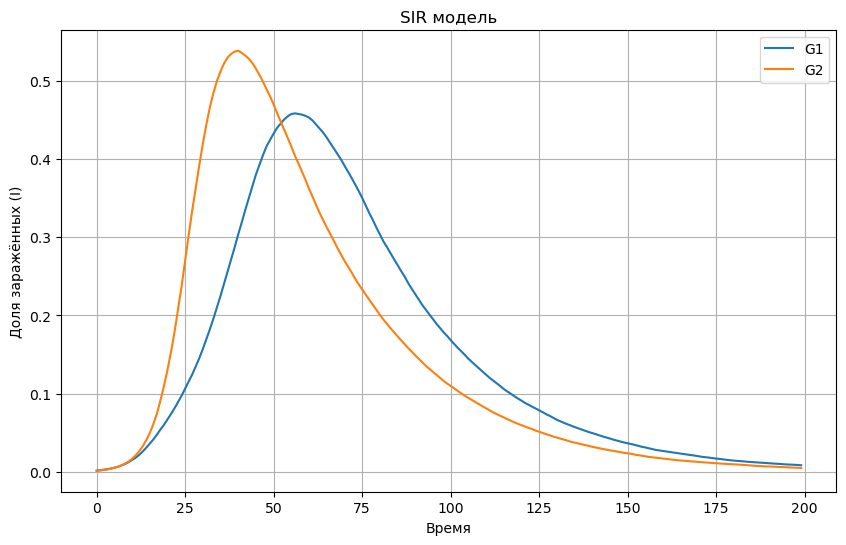


=== G1 ===
Вершины: 750
Рёбра: 22435
Средняя степень: 59.83
Максимальная степень: 82
Кластеризация: 0.7120
Средняя длина пути: 2.67

=== G2 ===
Вершины: 750
Рёбра: 22435
Средняя степень: 59.83
Максимальная степень: 82
Кластеризация: 0.0799
Средняя длина пути: 1.93


In [15]:
# приведение узлов к int (иногда graphml читает как строки)
# G1 = nx.convert_node_labels_to_integers(G1)
# G2 = nx.convert_node_labels_to_integers(G2)

# --- SIR модель ---
def run_sir(G, beta, gamma, n_iter, p0):
    nodes = list(G.nodes())
    N = len(nodes)
    
    # начально заражённые
    initial_infected = set(np.random.choice(nodes, size=int(N * p0), replace=False))
    
    S = set(nodes) - initial_infected
    I = set(initial_infected)
    R = set()
    
    infected_fraction = []
    
    for t in range(n_iter):
        new_I = set(I)
        new_R = set(R)
        
        # заражение
        for node in I:
            for neighbor in G.neighbors(node):
                if neighbor in S:
                    if np.random.rand() < beta:
                        new_I.add(neighbor)
        
        # выздоровление
        for node in I:
            if np.random.rand() < gamma:
                new_I.discard(node)
                new_R.add(node)
        
        S = set(nodes) - new_I - new_R
        I = new_I
        R = new_R
        
        infected_fraction.append(len(I) / N)
    
    return np.array(infected_fraction)


# --- усреднение ---
def simulate(G, name):
    all_runs = []
    
    for _ in range(n_run):
        all_runs.append(run_sir(G, beta, gamma, n_iter, percentage_infected))
    
    return np.mean(all_runs, axis=0)


res1 = simulate(G1, "G1")
res2 = simulate(G2, "G2")


# --- график ---
plt.figure(figsize=(10, 6))

plt.plot(res1, label='G1')
plt.plot(res2, label='G2')

plt.xlabel("Время")
plt.ylabel("Доля заражённых (I)")
plt.title("SIR модель")
plt.legend()
plt.grid()

plt.show()


# --- базовая топология ---
def analyze_graph(G, name):
    print(f"\n=== {name} ===")
    print(f"Вершины: {G.number_of_nodes()}")
    print(f"Рёбра: {G.number_of_edges()}")
    
    degrees = [d for _, d in G.degree()]
    print(f"Средняя степень: {np.mean(degrees):.2f}")
    print(f"Максимальная степень: {np.max(degrees)}")
    
    print(f"Кластеризация: {nx.average_clustering(G):.4f}")
    
    if nx.is_connected(G):
        print(f"Средняя длина пути: {nx.average_shortest_path_length(G):.2f}")
    else:
        print("Граф несвязный")

analyze_graph(G1, "G1")
analyze_graph(G2, "G2")

* Отличаются ли построенные зависимости?
Попробуйте понять, что влияет на распространение в сети, для этого исследуйте топологию G1, G2.

Графы существенно различаются по структуре:

| Характеристика | G1 | G2 |
|-|-|-|
| Кластеризация | 0.712 | 0.080 |
| Средняя длина пути | 2.67 | 1.93 |

В графе G2:
- пик заражения выше (~0.54),
- достигается раньше,
- эпидемия развивается быстрее.

В графе G1:
- пик ниже (~0.46),
- достигается позже,
- распространение более медленное.

### Кластеризация

В G1 высокая кластеризация:
- много "треугольников",
- соседи связаны между собой,
- инфекция распространяется внутри кластера, но медленно выходит наружу.

Возникает эффект "локализации инфекции".

В G2 (низкая кластеризация):
- связи более случайные,
- меньше перекрывающихся соседей.

Инфекция быстрее распространяется по всей сети.

### Средняя длина пути

- В G2 средняя длина пути меньше, поэтому быстрее достигаются удалённые вершины  
- G1 же длина больше, из-за чего распространение замедляется

* Поменяйте параметры модели, всегда ли распространение "чувствительно" к топологии сети?


beta=0.002, gamma=0.03


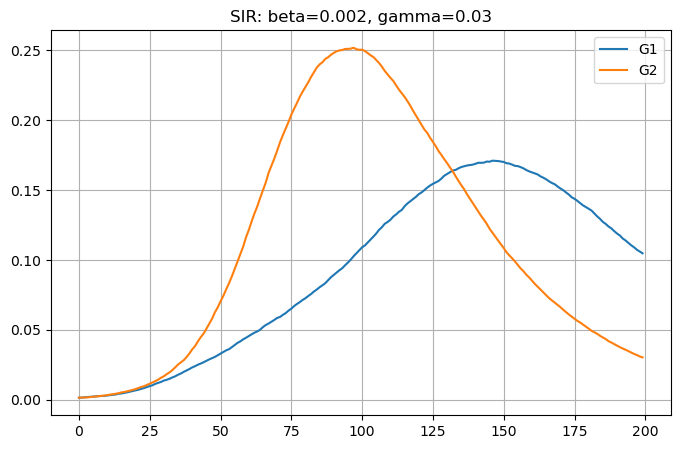


beta=0.01, gamma=0.03


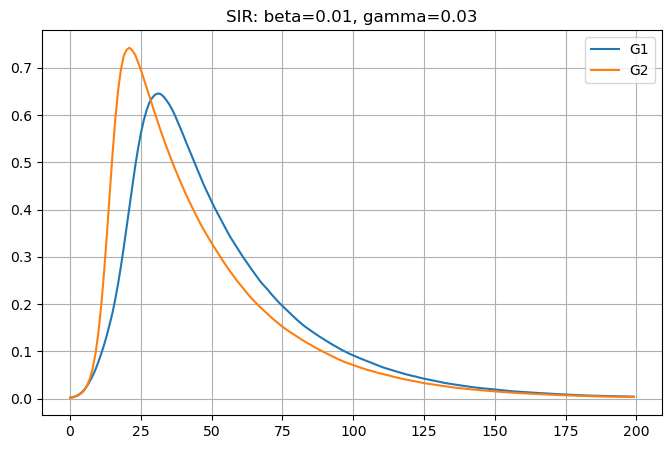

In [17]:
def run_experiment(beta, gamma):
    r1 = simulate(G1, "G1")
    r2 = simulate(G2, "G2")
    
    return r1, r2


# попробуем разные режимы
params = [
    (0.002, 0.03),  # слабая инфекция
    (0.01, 0.03),   # сильная инфекция
]

for beta_new, gamma_new in params:
    print(f"\nbeta={beta_new}, gamma={gamma_new}")
    
    beta = beta_new
    gamma = gamma_new
    
    r1, r2 = run_experiment(beta, gamma)
    
    plt.figure(figsize=(8,5))
    plt.plot(r1, label='G1')
    plt.plot(r2, label='G2')
    plt.title(f"SIR: beta={beta}, gamma={gamma}")
    plt.legend()
    plt.grid()
    plt.show()

### Чувствительность к параметрам

При малом значении $\beta$ различия между графами выражены довольно сильно: в $G2$ эпидемия развивается быстрее и достигает более высокого пика, тогда как в $G1$ распространение заметно замедлено. Это означает, что при слабом уровне заражения структура сети оказывает влияние на распрострранение.

При увеличении $\beta$ различия сглаживаются: кривые становятся похожими, и инфекция быстро распространяется в обоих графах. В этом случае влияние топологии уже не столь существенно.

Таким образом, чувствительность к структуре сети зависит от параметров модели. При слабом заражении именно топология определяет динамику, тогда как при сильном заражении её влияние снижается.